# $$ \textbf{Sinais e Sistemas Dinâmicos - Unidade 3}$$


Este Notebook é utilizado para o estudo da disciplina  **Sinais e Sistemas Dinâmicos** através da bibliografia 



- [Sinais e Sistemas Lineares, B. P. Lathi, ed. bookman, 2014]

Quando aplicável utilizaremos a tolboox processamento de sinais *scipy*, a biblioteca de computação simbólica *sympy*, dentre outras que se fizerem necessárias, do Python.


In [1]:
## Importação das bibliotecas Python, como indicado no texto ##

# biblioteca Python para matemática simbólica 
import sympy as sym
from sympy import* 

# Pacote para computação científica
import numpy as np

# biblioteca para a visualização de dados em Python.
import matplotlib.pyplot as plt

from pylab import plot, show

# Este módulo fornece acesso às funções matemáticas (definidas pelo padrão C)
import math

# cmath permite operações com números complexos
import cmath

# O módulo de frações fornece suporte para aritmética de números racionais
from fractions import Fraction

# permite usar latex para exibir equações matemáticas no Jupyter Notebook
from IPython.display import display, Math

#toolbox de processamento de sinais
from scipy import signal 

## 4. Análise de Sistemas em Tempo Contínuo usando a Transformada de Laplace




Devido à propriedade da linearidade (superposição) de sistemas lineares invariantes no tempo, podemos determinar a resposta destes sistemas dividindo a entrada $x(t)$ em várias componentes e, então, somando a resposta do sistema a todas estas componentes de $x(t)$. Já utilizamos esse procedimento na análise no domínio do tempo, na qual a entrada $x(t)$ é dividida em componentes impulsivas. 

Na análise no domínio da frequência estudada nesta unidade, dividimos a entrada $x(t)$ em exponenciais na forma $e^{s t}$, na qual o parâmetro $s$ é a frequência complexa do sinal $e^{s t}$. 

Esse método oferece uma visão do comportamento do sistema complementar à estudada na análise no domínio do tempo. De fato, os ``métodos de análise no domínio do tempo e no domínio da frequência são duais.``

A ferramenta que possibilita representar uma entrada arbitrária $x(t)$ em termos de componentes exponenciais é a ``transformada de Laplace``, a qual é discutida a seguir.

### 4.1 Transformada de Laplace

Para um sinal $x(t)$, a ``transformada de Laplace`` $X(s)$ é definida por
$$
X(s)=\int_{-\infty}^{\infty} x(t) e^{-s t} d t
$$

O sinal $x(t)$ é dito ser a ``transformada inversa de Laplace de`` $X(s)$. Pode ser mostrado que
$$
x(t)=\frac{1}{2 \pi j} \int_{c-j \infty}^{c+j \infty} X(s) e^{s t} d s
$$
onde $c$ é uma constante escolhida para garantir a convergência da integral acima (como explicado posteriormente).

Esse par de equações é conhecido como ``par da transformada de Laplace bilateral (ou simplesmente par de Laplace)``, no qual $X(s)$ é a transformada direta de Laplace de $x(t)$ e $x(t)$ é a transformada inversa de Laplace de $X(s)$. 

Simbolicamente,
$$
X(s)=\mathcal{L}[x(t)] \quad \text { e } \quad x(t)=\mathcal{L}^{-1}[X(s)]
$$

Observe que
$$
\mathcal{L}^{-1}\{\mathcal{L}[x(t)]\}=x(t) \quad \text { e } \quad \mathcal{L}\left\{\mathcal{L}^{-1}[X(s)]\right\}=X(s)
$$

Também é prática comum utilizar uma seta bidirecional para indicar o par da transformada de Laplace, como mostrado a seguir:
$$
x(t) \Longleftrightarrow X(s)
$$

A transformada de Laplace, definida desta forma, pode trabalhar com sinais que existem em todo o intervalo de tempo, de $-\infty$ a $\infty$ (sinais causais e não causais). Por essa razão, ela é chamada de transformada de Laplace bilateral (ou de dois lados). Mostraremos posteriormente um caso especial - a transformada de Laplace unilateral ou de um lado - a qual pode trabalhar apenas com sinais causais.

#### Linearidade da Transformada de Laplace

Provaremos agora que a transformada de Laplace é uma operação linear, mostrando que o princípio da superposição é válido, implicando que se
$$
x_1(t) \Longleftrightarrow X_1(s) \quad \text { e } \quad x_2(t) \Longleftrightarrow X_2(s)
$$
então
$$
a_1 x_1(t)+a_2 x_2(t) \Longleftrightarrow a_1 X_1(s)+a_2 X_2(s)
$$

A prova é simples. Por definição,
$$
\begin{aligned}
\mathcal{L}\left[a_1 x_1(t)+a_2 x_2(t)\right] & =\int_{-\infty}^{\infty}\left[a_1 x_1(t)+a_2 x_2(t)\right] e^{-s t} d t \\
& =a_1 \int_{-\infty}^{\infty} x_1(t) e^{-s t} d t+a_2 \int_{-\infty}^{\infty} x_2(t) e^{-s t} d t \\
& =a_1 X_1(s)+a_2 X_2(s)
\end{aligned}
$$

Este resultado pode ser estendido a qualquer soma finita.

#### A Região de Convergência (RDC)

A região de convergência (RDC), também chamada de região de existência, da transformada de Laplace $X(s)$, é o conjunto de valores de $s$ (a região no plano complexo) para os quais a integral da $X(s)=\int_{-\infty}^{\infty} x(t) e^{-s t} d t$ converge. Este conceito ficará mais claro com o exemplo a seguir:

#### Exemplo 4.1

Para um sinal $x(t)=e^{-a t} u(t)$, determine a transformada de Laplace $X(s)$ e sua RDC.

Pela definição,
$$
X(s)=\int_{-\infty}^{\infty} e^{-a t} u(t) e^{-s t} d t
$$

Como $u(t)=0$ para $t<0$, e $u(t)=1$ para $t \geq 0$,
$$
X(s)=\int_0^{\infty} e^{-a t} e^{-s t} d t=\int_0^{\infty} e^{-(s+a) t} d t=-\left.\frac{1}{s+a} e^{-(s+a) t}\right|_0 ^{\infty}
$$

Note que $s$ é complexo e quando $t \rightarrow \infty$, o termo $e^{-(s+a) t}$ não necessariamente desaparece. Lembramos que para um número complexo $z=\alpha+j \beta$,
$$
e^{-z t}=e^{-(\alpha+j \beta) t}=e^{-\alpha t} e^{-j \beta t}
$$

agora, $\left|e^{-j \beta t}\right|=1$, independente do valor de $\beta t$. Portanto, quando $t \rightarrow \infty, e^{-z t} \rightarrow 0$ somente se $\alpha>0$, e $e^{-z t} \rightarrow \infty$ se $\alpha<0$. Portanto,
$$
\lim _{t \rightarrow \infty} e^{-z t}= \begin{cases}0 & \operatorname{Re} z>0 \\ \infty & \operatorname{Re} z<0\end{cases}
$$

Claramente,
$$
\lim _{t \rightarrow \infty} e^{-(s+a) t}= \begin{cases}0 & \operatorname{Re}(s+a)>0 \\ \infty & \operatorname{Re}(s+a)<0\end{cases}
$$

Assim,
$$
X(s)=\frac{1}{s+a} \quad \operatorname{Re}(s+a)>0
$$
ou
$$
e^{-a t} u(t) \Longleftrightarrow \frac{1}{s+a} \quad \operatorname{Re} s>-a
$$

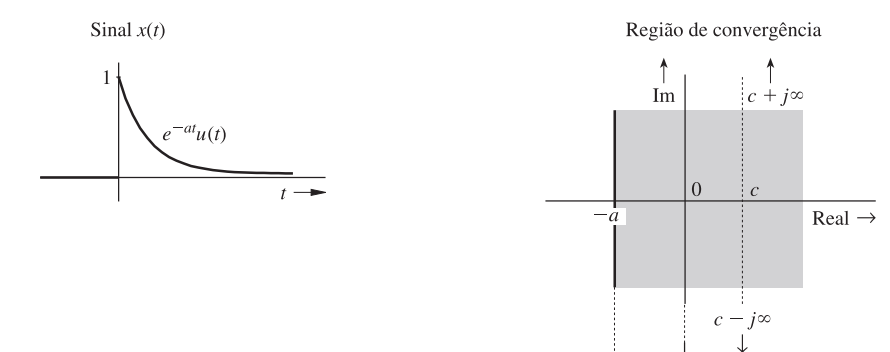

A RDC de $X(s)$ é Re $s>-a$, como mostrado na área sombreada da figura acima. Este fato implica em que a integral que define $X(s)$ existe somente para os valores de $s$ na região sombreada. Para outros valores de $s$, a integral não converge. Por esta razão, a região sombreada é chamada de RDC (ou região de existência) de $X(s)$.

#### Região de Convergência para Sinais de Duração Finita

Um sinal de duração finita $x_f(t)$ é um sinal que é não nulo somente para $t_1 \leq t \leq t_2$, em que tanto $t_1$ quanto $t_2$ são números finitos e $t_2>t_1$. Para um sinal de duração finita absolutamente integrável, a RDC é todo o plano $s$. Isto é claro do fato de que se $x_f(t)$ é absolutamente integrável e um sinal de duração finita, então $x_f(t) e^{-\sigma t}$ também é absolutamente integrável para qualquer valor de $\sigma$, pois a integração é para apenas uma faixa finita de $t$. 

Logo, a transformada de Laplace deste tipo de sinal converge para todo valor de $s$. Isto significa que a RDC de um sinal genérico $x(t)$ permanece inalterada quando $x(t)$ é somado a qualquer sinal $x_f(t)$ de duração finita e absolutamente integrável. Em outras palavras, se $\mathcal{R}$ representa a RDC do sinal $x(t)$, então a RDC de um sinal $x(t)$ $+x_f(t)$ também é $\mathcal{R}$.


#### Papel da Região de Convergência

A RDC é necessária para a determinação da transformada inversa de Laplace $x(t)$ de $X(s)$. A operação de determinação da transformada de Laplace requer uma integração no plano complexo, a qual precisa de algumas explicações. O caminho de integração é ao longo de $c+j \omega$, com $\omega$ variando de $-\infty$ a $\infty$. 

Além disso, o caminho de integração deve estar na RDC (ou existência) de $X(s)$. Para o sinal $e^{-a t} u(t)$, isto é possível se $c>-a$. Um possível caminho de integração é mostrado (em pontilhado) na figura abaixo. 


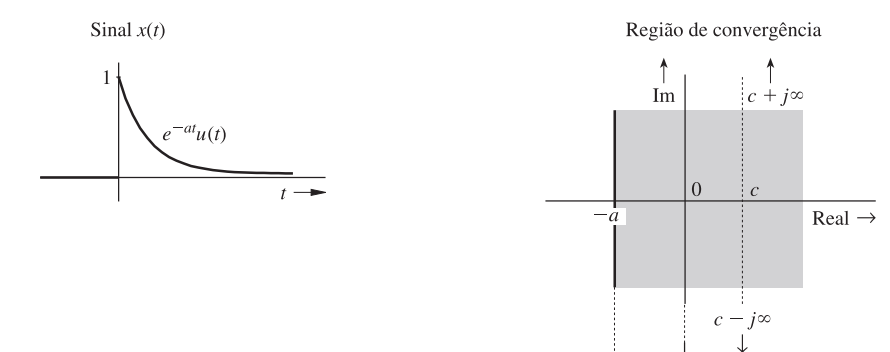


Portanto, para obter $x(t)$ de $X(s)$, a integração é executada ao longo deste caminho. Quando integramos $[1 /(s+a)] e^{s t}$ ao longo deste caminho, o resultado é $e^{-a t} u(t)$. Essa integração no plano complexo necessita de um conhecimento prévio da teoria de funções de variáveis complexas. 

Podemos evitar esta integração determinando uma tabela de transformadas de Laplace, na qual os pares de Laplace são tabulados para uma certa variedade de sinais. Para determinar a transformada inversa de Laplace de, digamos, $1 /(s+a)$, ao invés de utilizarmos uma integral complexa, procuramos na tabela e determinamos a transformada inversa de Laplace como sendo $e^{-a t} u(t)$ (assumindo que a RDC é $\operatorname{Re} s>-a$ ). 

Apesar de a tabela apresentada ser bem curta, ela possui as funções de maior interesse prático.

$$
\begin{aligned}
&\text { Tabela 4.1 Tabela (curta) de transformadas de Laplace (unilateral) }\\
&\begin{array}{lll}
\hline \mathbf{N}^0 & \boldsymbol{x}(t) & \boldsymbol{X}(s) \\
\hline 1 & \delta(t) & 1 \\
2 & u(t) & \frac{1}{s} \\
3 & t u(t) & \frac{1}{s^2} \\
4 & t^n u(t) & \frac{n !}{s^{n+1}} \\
5 & e^{\lambda t} u(t) & \frac{1}{s-\lambda} \\
6 & t e^{\lambda t} u(t) & \frac{1}{(s-\lambda)^2} \\
7 & t^n e^{\lambda t} u(t) & \frac{n !}{(s-\lambda)^{n+1}} \\
8a &  \cos (b t) u(t) & \frac{s}{s^2+b^2}\\
8b & \operatorname{sen} (b t) u(t) & \frac{b}{s^2+b^2} \\
9a & e^{-a t} \cos (b t) u(t) & \frac{s+a}{(s+a)^2+b^2} \\
9b & e^{-a t} \operatorname{sen} (b t) u(t) & \frac{b}{(s+a)^2+b^2}\\
10a & r e^{-a t} \cos (b t+\theta) u(t) & \frac{(r \cos \theta) s+(a r \cos \theta-b r \operatorname{sen} \theta)}{s^2+2 a s+\left(a^2+b^2\right)} \\
10b & r e^{-a t} \cos (b t+\theta) u(t) & \frac{0,5 r e^{j \theta}}{s+a-j b}+\frac{0,5 r e^{-j \theta}}{s+a+j b} \\
10c & r e^{-a t} \cos (b t+\theta) u(t) & \frac{A s+B}{s^2+2 a s+c} \\
& r =\sqrt{\frac{A^2 c+B^2-2 A B a}{c-a^2}} & \\
&\theta =\tan ^{-1}\left(\frac{A a-B}{A \sqrt{c-a^2}}\right) & \\
& b =\sqrt{c-a^2} & \\
10d &  e^{-a t}\left[A \cos (b t) +\frac{B-A a}{b} \operatorname{sen} (b t)\right] u(t) & \frac{A s+B}{s^2+2 a s+c} & \\
& b =\sqrt{c-a^2}
\end{array}
\end{aligned}
$$

#### A Transformada de Laplace Unilateral

Para compreender a necessidade da determinação da transformada unilateral, vamos determinar a transformada de Laplace do sinal $x(t)$ mostrado na figura abaixo.


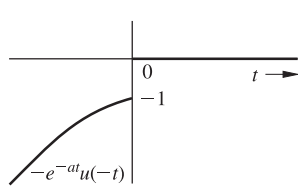
$$
x(t)=-e^{-a t} u(-t)
$$


A transformada de Laplace desse sinal é
$$
X(s)=\int_{-\infty}^{\infty}-e^{-a t} u(-t) e^{-s t} d t
$$

Como $u(-t)=1$ para $t<0$ e $u(-t)=0$ para $t>0$,
$$
X(s)=\int_{-\infty}^0-e^{-a t} e^{-s t} d t=-\int_{-\infty}^0 e^{-(s+a) t} d t=\left.\frac{1}{s+a} e^{-(s+a) t}\right|_{-\infty} ^0
$$

De onde,
$$
\lim _{t \rightarrow-\infty} e^{-(s+a) t}=0 \quad \operatorname{Re}(s+a)<0
$$

Logo
$$
X(s)=\frac{1}{s+a} \quad \operatorname{Re} s<-a
$$

A RDC do sinal $-e^{a t} u(-t)$ é mostrada na figura abaixo.

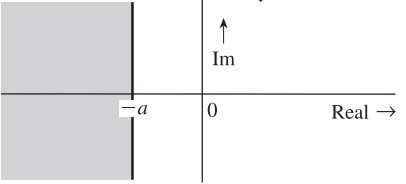

Note que a transformada de Laplace para os sinais $e^{-a t} u(t)$ e $-e^{a t} u(-t)$ são idênticas, exceto por suas regiões de convergência. Portanto, para um dado $X(s)$, existe mais de uma transformada inversa, dependendo da RDC. Em outras palavras, a não ser que a RDC seja especificada, não existe uma convergência de um-para-um entre $X(s)$ e $x(t)$. 

Esse fato aumenta de complexidade na utilização da transformada de Laplace. A complexidade é o resultado de tentar trabalhar com sinais causais e não causais. Se restringirmos todos os nossos sinais ao tipo causal, esta ambigüidade desaparece. Existe apenas uma transformada inversa de $X(s)=1 /(s+a)$, notadamente $e^{-a t} u(t)$. Para determinar $x(t)$ de $X(s)$, nem precisamos especificar a RDC. Em resumo, ``se todos os sinais forem restritos ao tipo causal, então, para uma dada`` $X(s)$ ``existe uma única transformada inversa`` $x(t)$.

A transformada de Laplace unilateral é um caso especial da transformada de Laplace bilateral na qual todos os sinais são restritos a serem causais. Consequentemente, os limites da integração podem ser considerados de 0 a $\infty$. Logo, a transformada de Laplace unilateral $X(s)$ de um sinal $x(t)$ é definida por
$$
X(s)=\int_{0^{-}}^{\infty} x(t) e^{-s t} d t
$$

Escolhemos $0^{-}$(no lugar de $0^{+}$ utilizado em alguns textos) como limite inferior de integração. Esta convenção não apenas garante a inclusão de uma função impulso em $t=0$, mas também permite utilizarmos condições iniciais para $0^{-}$(no lugar de $0^{+}$) na solução de equações diferenciais pela transformada de Laplace. Na prática provavelmente conheceremos as condições iniciais antes da entrada ser aplicada (em $0^{-}$) e não após a entrada ser aplicada (em $0^{+}$). 

De fato, o verdadeiro significado do termo "condições iniciais" implica em condições para $t=$ $0^{-}$(condições antes da entrada ser aplicada). 

A transformada de Laplace unilateral simplifica consideravelmente o problema de análise de sistemas, devido a sua propriedade de exclusividade, a qual diz que para um dado $X(s)$ existe uma única transformada inversa. Mas existe um preço por esta simplificação: não podemos analisar sistemas ou entradas não causais. Entretanto, na maioria dos problemas práticos, esta restrição não tem consequência. Por esta razão, iremos considerar primeiro a transformada de Laplace unilateral e sua aplicação a análise de sistemas.

Basicamente não existe diferença entre a transformada de Laplace unilateral e bilateral. A transformada unilateral é a transformada bilateral que trabalha com uma subclasse de sinais, começando em $t=0$ (sinais causais). Portanto, a expressão para a transformada inversa de Laplace permanece inalterada. ``Na prática, o termo transformada de Laplace significa a transformada de Laplace unilateral.``


#### Existência da Transformada de Laplace

A variável $s$ da transformada de Laplace é, geralmente, complexa e pode ser descrita por $s=\sigma+j \omega$. Por definição,
$$
\begin{aligned}
X(s) & =\int_{0^{-}}^{\infty} x(t) e^{-s t} d t \\
& =\int_{0^{-}}^{\infty}\left[x(t) e^{-\sigma t}\right] e^{-j \omega t} d t
\end{aligned}
$$

Como $\left|e^{j \omega t}\right|=1$, a integral do lado direito desta equação converge se
$$
\int_{0^{-}}^{\infty}\left|x(t) e^{-\sigma t}\right| d t<\infty
$$

Logo, a existência da transformada de Laplace está garantida se a integral acima for finita para algum valor de $\sigma$. Qualquer sinal que não cresce mais rápido do que o sinal exponencial $M e^{\sigma_{0 t}}$ para algum $M$ e $\sigma_0$ satisfaz a condição de convergência acima. Portanto, se para algum $M$ e $\sigma_0$,
$$
|x(t)| \leq M e^{\sigma_0 t}
$$
podemos escolher $\sigma>\sigma_0$ para satisfazer $\int_{0^{-}}^{\infty}\left|x(t) e^{-\sigma t}\right| d t<\infty$. 

O sinal $e^{t^2}$, ao contrário, cresce com uma taxa maior do que $e^{\sigma_0 t}$ $\mathrm{e}$, consequentemente, não possui transformada de Laplace. 

Felizmente, tais sinais (que não possuem transformada de Laplace) são de pouca consequência do ponto de vista prático ou teórico. Se $\sigma_0$ é o menor valor de $\sigma$ para o qual a integral em acima é finita, $\sigma_0$ é chamado de ``abscissa de convergência`` e a RDC de $X(s)$ é $\operatorname{Re} s>\sigma_0$. A abscissa de convergência para $e^{-a t} u(t)$ é $-a$ (a RDC é $\operatorname{Re} s>-a)$.

#### Exemplo 4.2

Determine a transformada de Laplace dos seguintes sinais:

(a) $\delta(t)$

(b) $u(t)$

(c) $\cos \omega_0 t u(t)$

(a)
$$
\mathcal{L}[\delta(t)]=\int_{0^{-}}^{\infty} \delta(t) e^{-s t} d t
$$

Usando a propriedade de amostragem, temos
$$
\mathcal{L}[\delta(t)]=1 \quad \text { para todo } s
$$

Ou seja,
$$
\delta(t) \Longleftrightarrow 1 \quad \text { para todo } s
$$

(b) Para determinar a transformada de Laplace de $u(t)$, lembre-se que $u(t)=1$ para $t \geq 0$. Portanto,
$$
\begin{aligned}
\mathcal{L}[u(t)] & =\int_{0^{-}}^{\infty} u(t) e^{-s t} d t=\int_{0^{-}}^{\infty} e^{-s t} d t=-\left.\frac{1}{s} e^{-s t}\right|_{0^{-}} ^{\infty} \\
& =\frac{1}{s} \quad \operatorname{Re} s>0
\end{aligned}
$$

Também poderíamos ter obtido este resultado a partir de
$$
e^{-a t} u(t) \Longleftrightarrow \frac{1}{s+a} \quad \operatorname{Re} s>-a,
$$
fazendo $a=0$.

(c) Como
$$
\begin{aligned}
\cos \omega_0 t u(t) & =\frac{1}{2}\left[e^{j \omega_0 t}+e^{-j \omega_0 t}\right] u(t) \\
\mathcal{L}\left[\cos \omega_0 t u(t)\right] & =\frac{1}{2} \mathcal{L}\left[e^{j \omega_0 t} u(t)+e^{-j \omega_0 t} u(t)\right]
\end{aligned}
$$

A partir de
$$
e^{-a t} u(t) \Longleftrightarrow \frac{1}{s+a} \quad \operatorname{Re} s>-a,
$$
obtemos
$$
\begin{aligned}
\mathcal{L}\left[\cos \omega_0 t u(t)\right] & =\frac{1}{2}\left[\frac{1}{s-j \omega_0}+\frac{1}{s+j \omega_0}\right] \quad \operatorname{Re}(s \pm j \omega)=\operatorname{Re} s>0 \\
& =\frac{s}{s^2+\omega_0^2} \quad \operatorname{Re} s>0
\end{aligned}
$$

Para a transformada de Laplace unilateral, existe uma única transformada inversa de $X(s)$, Consequentemente, não há necessidade de especificar a RDC explicitamente. Por esta razão, geralmente ignoramos qualquer menção a RDC para transformadas unilaterais. Lembre-se, também, que na transformada de Laplace unilateral subentende-se que todo sinal $x(t)$ é zero para $t<0$, sendo apropriado indicar este fato pela multiplicação do sinal com $u(t)$.

#### 4.1.1 Determinando a Transformada Inversa

A determinação da transformada inversa de Laplace utilizando a definição requer a integração no plano complexo, um tópico além do escopo deste curso. Para o nosso propósito, podemos determinar as transformadas inversas a partir da tabela de transformadas (Tabela 4.1). Tudo o que precisamos é expressar $X(s)$ como a soma de funções mais simples, nas formas listadas na tabela. 

A maioria das transformadas $X(s)$ de interesse prático são funções racionais, ou seja, razões de polinômios em $s$. Tais funções podem ser expressadas como a soma de funções mais simples usando a expansão em frações parciais.

``Os valores de`` $s$ ``para os quais`` $X(s)=0$ ``são chamados de zeros de`` $X(s)$ ``e os valores de`` $s$ ``para os quais`` $X(s) \rightarrow$ $\infty$ ``são chamados de pólos de`` $X(s)$. Se $X(s)$ é uma função racional na forma $P(s) / Q(s)$, as raízes de $P(s)$ são os zeros e as raízes de $Q(s)$ são os pólos de $X(s)$.


#### Exemplo 4.3

Determine a transformada inversa de Laplace de

(a) $\frac{7 s-6}{s^2-s-6}$

(b) $\frac{2 s^2+5}{s^2+3 s+2}$

Em nenhum desses casos a transformada inversa pode ser obtida diretamente da Tabela 4.1. Precisamos expandir estas funções em frações parciais.


(a)
$$
X(s) =\frac{7 s-6}{(s+2)(s-3)} =\frac{k_1}{s+2}+\frac{k_2}{s-3}=\frac{4}{s+2}+\frac{3}{s-3}
$$

Usando o par 5 da Tabela 4.1, obtemos
$$
x(t)=\mathcal{L}^{-1}\left(\frac{4}{s+2}+\frac{3}{s-3}\right)=\left(4 e^{-2 t}+3 e^{3 t}\right) u(t)
$$

(b)
$$
X(s)=\frac{2 s^2+5}{s^2+3 s+2}=\frac{2 s^2+5}{(s+1)(s+2)}
$$

Observe que $X(s)$ é uma função imprópria com $M=N$. Neste caso podemos expressar $X(s)$ como a soma dos coeficientes de mais alta potência do numerador mais as frações parciais correspondentes aos pólos de $X(s)$. Como o coeficiente de mais alta potência do numerador é 2, temos
$$
X(s)=2+\frac{k_1}{s+1}+\frac{k_2}{s+2}=2+\frac{7}{s+1}-\frac{13}{s+2}
$$

A partir da Tabela 4.1, pares 1 e 5 , temos
$$
x(t)=2 \delta(t)+\left(7 e^{-t}-13 e^{-2 t}\right) u(t)
$$

#### Tabela 4.2 Propriedades da transformada de Laplace

| Operação | $\boldsymbol{x}(\boldsymbol{t})$ | $\boldsymbol{X}(\boldsymbol{s})$ |
| :--- | :--- | :--- |
| Adição | $x_1(t)+x_2(t)$ | $X_1(s)+X_2(s)$ |
| Multiplicação escalar | $k x(t)$ | $k X(s)$ |
| Diferenciação no tempo | $\frac{d x}{d t}$ | $s X(s)-x\left(0^{-}\right)$ |
|  | $\frac{d^2 x}{d t^2}$ | $s^2 X(s)-s x\left(0^{-}\right)-\dot{x}\left(0^{-}\right)$ |
|  | $\frac{d^3 x}{d t^3}$ | $s^3 X(s)-s^2 x\left(0^{-}\right)-s \dot{x}\left(0^{-}\right)-\ddot{x}\left(0^{-}\right)$ |
|  | $\frac{d^n x}{d t^n}$ | $s^n X(s)-\sum_{k=1}^n s^{n-k} x^{(k-1)}\left(0^{-}\right)$ |
| Integração no tempo | $\int_{0^{-}}^t x(\tau) d \tau$ | $\frac{1}{s} X(s)$ |
|  | $\int_{-\infty}^t x(\tau) d \tau$ | $\frac{1}{s} X(s)+\frac{1}{s} \int_{-\infty}^{0^{-}} x(t) d t$ |
| Deslocamento no tempo | $x\left(t-t_0\right) u\left(t-t_0\right)$ | $X(s) e^{-s t_0} \quad t_0 \geq 0$ |
| Deslocamento em <br> frequência | $x(t) e^{s_0 t}$ | $X\left(s-s_0\right)$ |
| Diferenciação em <br> frequência | $-t x(t)$ | $\frac{d X(s)}{d s}$ |
| Integração em frequência | $\frac{x(t)}{t}$ | $\int_s^{\infty} X(z) d z$ |
| Escalonamento | $x(a t), a \geq 0$ | $\frac{1}{a} X\left(\frac{s}{a}\right)$ |
| Convolução no tempo | $x_1(t) * x_2(t)$ | $X_1(s) X_2(s)$ |
| Convolução na frequência | $x_1(t) x_2(t)$ | $\frac{1}{2 \pi j} X_1(s) * X_2(s)$ |
| Valor inicial | $x\left(0^{+}\right)$ | $\lim _{s \rightarrow \infty} s(s) \quad(n>m)$ |
| Valor final | $x(\infty)$ | $\lim _{s \rightarrow 0} s X(s) \quad$ [pólo de $s X(s)$ no SPE] |

Em certas aplicações, é necessário conhecer os valores de $x(t)$ quando $t \rightarrow 0$ e $t \rightarrow \infty$ [valores inicial e final de $x(t)$ ] a partir do conhecimento de sua transformada de Laplace $X(s)$. Os teoremas do valor inicial e do valor final fornecem esta informação.

``O teorema do valor inicial`` afirma que se $x(t)$ e sua derivada $d x / d t$ podem ser transformadas por Laplace, então
$$
x\left(0^{+}\right)=\lim _{s \rightarrow \infty} s X(s)
$$
desde que o limite do lado direito da Eq. (4.33) exista.


``O teorema do valor final`` afirma que se $x(t)$ e sua derivada $d x / d t$ podem ser transformadas por Laplace, então
$$
\lim _{t \rightarrow \infty} x(t)=\lim _{s \rightarrow 0} s X(s)
$$

desde que $s X(s)$ não possua pólos no SPD ou no eixo imaginário. Para provar estes teoremas, utilizamos a equação $\frac{d x}{d t} \Longleftrightarrow s X(s)-x\left(0^{-}\right)$
$$
\begin{aligned}
s X(s)-x\left(0^{-}\right) & =\int_{0^{-}}^{\infty} \frac{d x}{d t} e^{-s t} d t \\
& =\int_{0^{-}}^{0^{+}} \frac{d x}{d t} e^{-s t} d t+\int_{0^{+}}^{\infty} \frac{d x}{d t} e^{-s t} d t \\
& =\left.x(t)\right|_{0^{-}} ^{0^{+}}+\int_{0^{+}}^{\infty} \frac{d x}{d t} e^{-s t} d t \\
& =x\left(0^{+}\right)-x\left(0^{-}\right)+\int_{0^{+}}^{\infty} \frac{d x}{d t} e^{-s t} d t
\end{aligned}
$$

Portanto,
$$
s X(s)=x\left(0^{+}\right)+\int_{0^{+}}^{\infty} \frac{d x}{d t} e^{-s t} d t
$$

e
$$
\begin{aligned}
\lim _{s \rightarrow \infty} s X(s) & =x\left(0^{+}\right)+\lim _{s \rightarrow \infty} \int_{0^{+}}^{\infty} \frac{d x}{d t} e^{-s t} d t \\
& =x\left(0^{+}\right)+\int_{0^{+}}^{\infty} \frac{d x}{d t}\left(\lim _{s \rightarrow \infty} e^{-s t}\right) d t \\
& =x\left(0^{+}\right)
\end{aligned}
$$

#### Exemplo 4.4

Determine os valores inicial e final de $y(t)$ se sua transformada de Laplace $Y(s)$ for dada por
$$
Y(s)=\frac{10(2 s+3)}{s\left(s^2+2 s+5\right)}
$$

Usando os resultados acima, obtemos

$$
\begin{aligned}
& y\left(0^{+}\right)=\lim _{s \rightarrow \infty} s Y(s)=\lim _{s \rightarrow \infty} \frac{10(2 s+3)}{\left(s^2+2 s+5\right)}=0 \\
& y(\infty)=\lim _{s \rightarrow 0} s Y(s)=\lim _{s \rightarrow 0} \frac{10(2 s+3)}{\left(s^2+2 s+5\right)}=6
\end{aligned}
$$

#### 4.3 Solução de Equações Diferenciais e Integro-Diferenciais

A propriedade de diferenciação no tempo da transformada de Laplace possibilita a resolução de equações diferenciais (ou integro-diferenciais) lineares com coeficientes constantes. 

Como $d^k y / d t^k \Longleftrightarrow s^k Y(s)$, a transformada de Laplace de uma equação diferencial é uma equação algébrica que pode ser facilmente resolvida para $Y(s)$. A seguir determinamos a transformada inversa de Laplace de $Y(s)$ para obtermos a solução $y(t)$ desejada. 

Os exemplos a seguir demonstram o procedimento da transformada de Laplace na resolução de equações diferenciais lineares com coeficientes constantes.

#### Exemplo 4.5

Resolva a equação diferencial linear de segunda ordem
$$
\left(D^2+5 D+6\right) y(t)=(D+1) x(t)
$$
para as condições iniciais $y\left(0^{-}\right)=2 \mathrm{e}\left(0^{-}\right)=1$ e entrada $x(t)=e^{-4 t} u(t)$.


A equação é
$$
\frac{d^2 y}{d t^2}+5 \frac{d y}{d t}+6 y(t)=\frac{d x}{d t}+x(t)
$$

Considerando
$$
y(t) \Longleftrightarrow Y(s)
$$

Então,
$$
\frac{d y}{d t} \Longleftrightarrow s Y(s)-y\left(0^{-}\right)=s Y(s)-2
$$
e
$$
\frac{d^2 y}{d t^2} \Longleftrightarrow s^2 Y(s)-s y\left(0^{-}\right)-\dot{y}\left(0^{-}\right)=s^2 Y(s)-2 s-1
$$

Além disso, para $x(t)=e^{-4 t} u(t)$,
$$
X(s)=\frac{1}{s+4} \quad \text { e } \quad \frac{d x}{d t} \Longleftrightarrow s X(s)-x\left(0^{-}\right)=\frac{s}{s+4}-0=\frac{s}{s+4}
$$

Fazendo a transformada de Laplace, obtemos
$$
\left[s^2 Y(s)-2 s-1\right]+5[s Y(s)-2]+6 Y(s)=\frac{s}{s+4}+\frac{1}{s+4}
$$

Agrupando todos os termos de $Y(s)$ e mantendo os termos restantes separados no lado esquerdo, temos
$$
\left(s^2+5 s+6\right) Y(s)-(2 s+11)=\frac{s+1}{s+4}
$$

Portanto,
$$
\left(s^2+5 s+6\right) Y(s)=(2 s+11)+\frac{s+1}{s+4}=\frac{2 s^2+20 s+45}{s+4}
$$

e
$$
\begin{aligned}
Y(s) & =\frac{2 s^2+20 s+45}{\left(s^2+5 s+6\right)(s+4)} \\
& =\frac{2 s^2+20 s+45}{(s+2)(s+3)(s+4)}
\end{aligned}
$$

Expandindo o lado direito em frações parciais,
$$
Y(s)=\frac{13 / 2}{s+2}-\frac{3}{s+3}-\frac{3 / 2}{s+4}
$$

A transformada inversa de Laplace dessa equação resulta em
$$
y(t)=\left(\frac{13}{2} e^{-2 t}-3 e^{-3 t}-\frac{3}{2} e^{-4 t}\right) u(t)
$$

O exemplo acima mostra a facilidade com a qual a transformada de Laplace pode resolver equações diferenciais lineares com coeficientes constantes. O método é genérico e pode resolver uma equação diferencial linear com coeficientes constantes de qualquer ordem.

#### Componente de Entrada Nula e Estado Nulo da Resposta

O método da transformada de Laplace fornece a resposta total, a qual inclui as componentes de entrada nula e estado nulo. É possível separar as duas componentes se for necessário. Os termos da resposta referentes às condições iniciais são oriundos da resposta de entrada nula. Por exemplo, no Exemplo 4.5, os termos atribuídos às condições iniciais $y\left(0^{-}\right)=2$ e $\dot{y}\left(0^{-}\right)=1$ geram a resposta de entrada nula. Esses termos são $-(2 s$ + 11). Os termos do lado direito da equação são exclusivamente devidos à entrada. 

A equação 
$$
\left(s^2+5 s+6\right) Y(s)-(2 s+11)=\frac{s+1}{s+4}
$$
é reproduzida a seguir identificando-se os termos de tal forma que
$$
\left(s^2+5 s+6\right) Y(s)=\underbrace{(2 s+11)}_{\text {termos de condições iniciais }}+\underbrace{\frac{s+1}{s+4}}_{\text {termos de entrada }}
$$

Logo, 
$$
\begin{aligned}
Y(s) & =\underbrace{\frac{2 s+11}{s^2+5 s+6}}_{\text {componente de entrada nula }}+\underbrace{\frac{s+1}{(s+4)\left(s^2+5 s+6\right)}}_{\text {componente de estado nulo }} \\
& =\left[\frac{7}{s+2}-\frac{5}{s+3}\right]+\left[\frac{-1 / 2}{s+2}+\frac{2}{s+3}-\frac{3 / 2}{s+4}\right]
\end{aligned}
$$

Obtendo a transformada inversa desta equação,
$$
y(t)=\underbrace{\left(7 e^{-2 t}-5 e^{-3 t}\right) u(t)}_{\text {resposta de entrada nula }}+\underbrace{\left(-\frac{1}{2} e^{-2 t}+2 e^{-3 t}-\frac{3}{2} e^{-4 t}\right) u(t)}_{\text {resposta de estado nulo }}
$$

### $ 3^a$ Lista de Exercícios

#### 1.  Determine a transformada inversa de Laplace de

(a) $\frac{6(s+34)}{s\left(s^2+10 s+34\right)}$

(b) $\frac{8 s+10}{(s+1)(s+2)^3}$


#### 2. Através da integração, determine a transformada de Laplace $X(s)$ e a região de convergência de $X(s)$ para os sinais mostrados abaixo.


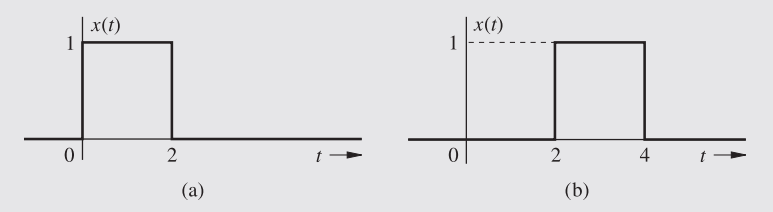

#### 3. Mostre que a transformada de Laplace de 

$10 e^{-3 t} \cos \left(4 t+53,13^{\circ}\right)$ é $(6 s-14) /\left(s^2+6 s+25\right)$

(Use o par 10a da Tabela 4.1.)

#### 4.  Determine a transformada inversa de Laplace de:

(a) $\frac{s+17}{s^2+4 s-5}$

(b) $\frac{3 s-5}{(s+1)\left(s^2+2 s+5\right)}$

(c) $\frac{16 s+43}{(s-2)(s+3)^2}$

#### 5.  Determine a transformada de Laplace de $x(t)$  mostrada na figura abaixo.

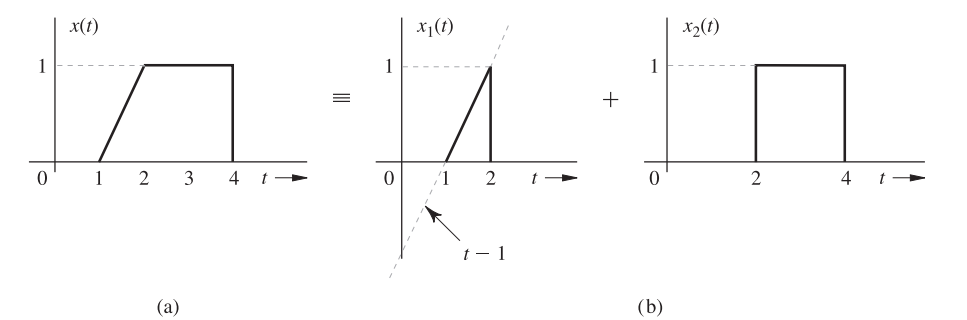

#### 6.  Determine a transformada de Laplace de $x(t)$  mostrada na figura abaixo.


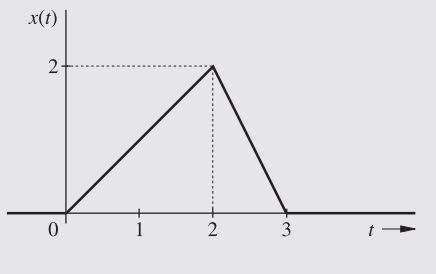

#### 7. Determine a transformada inversa de Laplace de
$$
X(s)=\frac{3 e^{-2 s}}{(s-1)(s+2)}
$$

#### 8. Resolva
$$
\frac{d^2 y}{d t^2}+4 \frac{d y}{d t}+3 y(t)=2 \frac{d x}{d t}+x(t)
$$
para a entrada $x(t)=u(t)$. As condições iniciais são $y\left(0^{-}\right)=1$ e $\dot{y}\left(0^{-}\right)=2$.

#### 9. Para um sistema LCIT com função de transferência
$$
H(s)=\frac{s+5}{s^2+4 s+3}
$$

(a) Descreva a equação diferencial que relaciona a entrada $x(t)$ e a saída $y(t)$.

(b) Determine a resposta $y(t)$ do sistema a entrada $x(t)=e^{-2 t} u(t)$ se o sistema estiver inicialmente em estado nulo.

#### 10. Usando a transformada de Laplace, resolva as seguintes equações diferenciais:
(a)
$$
\begin{aligned}
& \left(D^2+3 D+2\right) y(t)=D x(t) \text { se } \\
& y\left(0^{-}\right)= \dot{y}\left(0^{-}\right)=0 \text { e } x(t)=u(t)
\end{aligned}
$$

(b)
$$
\begin{aligned}
& \left(D^2+4 D+4\right) y(t)=(D+1) x(t) \text { se } \\
& y\left(0^{-}\right)=2, \dot{y}\left(0^{-}\right)=1 \text{ e } x(t)=e^{-t} u(t)
\end{aligned}
$$

(c)
$$
\begin{aligned}
& \left(D^2+6 D+25\right) y(t)=(D+2) x(t) \text{ se } \\
& y\left(0^{-}\right)=\dot{y}\left(0^{-}\right)=1 \text{ e } x(t)=25 u(t)
\end{aligned}
$$
